In [4]:
# Cell 1: imports & setup

import os
import sys
import numpy as np
import pandas as pd
import torch
import lightning.pytorch as pl
import matplotlib.pyplot as plt

from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

from torch.utils.data import DataLoader
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

pl.seed_everything(42, workers=True)

# --- project root (where technicals.indicators lives) ---
project_root = r"C:\Users\admin\Desktop\Forex_algo\code"
if project_root not in sys.path:
    sys.path.append(project_root)

from technicals.indicators import add_standard_indicators

# --- data paths (adapt if needed) ---
DATA_H1 = r"C:\Users\admin\Desktop\Forex_algo\code\Data\EUR_USD_H1.parquet"
DATA_H4 = r"C:\Users\admin\Desktop\Forex_algo\code\Data\EUR_USD_H4.parquet"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Torch:", torch.__version__)
print("Lightning:", pl.__version__)


Seed set to 42


Using device: cuda
Torch: 2.5.1+cu121
Lightning: 2.5.6


In [5]:
# Cell 2: prepare H1 data with indicators

FEATURE_COLS_H1 = [
    "mid_o", "mid_h", "mid_l", "mid_c",
    "volume", "log_volume",
    "rsi",
    "macd", "macd_signal", "macd_hist",
    "atr14",
    "bb_lower", "bb_middle", "bb_upper",
    "ema_5", "ema_20", "ema_50", "ema_200",
    "momentum_oc", "avg_price_hl", "range_hl", "typical_price_ohlc",
]

def prepare_h1_with_indicators(df_h1_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_h1_raw.copy()
    df["time"] = pd.to_datetime(df["time"], utc=True)

    # basic price/volume
    df["close"] = df["mid_c"]

    # apply your standard indicators
    df = add_standard_indicators(df)

    # engineered features
    df["momentum_oc"] = df["mid_c"] - df["mid_o"]
    df["avg_price_hl"] = (df["mid_h"] + df["mid_l"]) / 2.0
    df["range_hl"] = df["mid_h"] - df["mid_l"]
    df["typical_price_ohlc"] = (
        df["mid_o"] + df["mid_h"] + df["mid_l"] + df["mid_c"]
    ) / 4.0

    df["log_volume"] = np.log1p(df["volume"])

    df = df.dropna().reset_index(drop=True)
    return df

df_h1_raw = pd.read_parquet(DATA_H1)
df_h1 = prepare_h1_with_indicators(df_h1_raw)

print("H1 shape (with indicators):", df_h1.shape)
print(df_h1.head())


H1 shape (with indicators): (61274, 43)
                       time  volume    mid_o    mid_h    mid_l    mid_c  \
0 2016-01-19 07:00:00+00:00    1298  1.08736  1.08764  1.08595  1.08652   
1 2016-01-19 08:00:00+00:00    1450  1.08654  1.08846  1.08636  1.08846   
2 2016-01-19 09:00:00+00:00    1626  1.08844  1.08890  1.08702  1.08724   
3 2016-01-19 10:00:00+00:00    1376  1.08728  1.08834  1.08662  1.08730   
4 2016-01-19 11:00:00+00:00     941  1.08728  1.08732  1.08599  1.08630   

     bid_o    bid_h    bid_l    bid_c  ...     atr14     ema_5    ema_20  \
0  1.08726  1.08756  1.08587  1.08645  ...  0.001128  1.087710  1.088764   
1  1.08647  1.08832  1.08629  1.08832  ...  0.001199  1.087960  1.088735   
2  1.08834  1.08883  1.08694  1.08699  ...  0.001283  1.087720  1.088593   
3  1.08702  1.08827  1.08655  1.08722  ...  0.001351  1.087580  1.088470   
4  1.08721  1.08726  1.08593  1.08623  ...  0.001391  1.087153  1.088263   

     ema_50   ema_200  momentum_oc  avg_price_hl  ra

In [6]:
# Cell 3: prepare H4 data with target

def prepare_h4_with_target(df_h4_raw: pd.DataFrame) -> pd.DataFrame:
    df = df_h4_raw.copy()
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df["close"] = df["mid_c"]

    # target = next 4H log-return
    df["target_return_4h"] = np.log(df["close"].shift(-1)) - np.log(df["close"])

    # time features (for H4 bar)
    df["hour"] = df["time"].dt.hour.astype(str)
    df["day_of_week"] = df["time"].dt.dayofweek.astype(str)

    return df

df_h4_raw = pd.read_parquet(DATA_H4)
df_h4 = prepare_h4_with_target(df_h4_raw)

print("H4 shape (with target):", df_h4.shape)
print(df_h4[["time", "close", "target_return_4h"]].head())


H4 shape (with target): (15375, 18)
                       time    close  target_return_4h
0 2016-01-06 22:00:00+00:00  1.08029          0.002247
1 2016-01-07 02:00:00+00:00  1.08272          0.001735
2 2016-01-07 06:00:00+00:00  1.08460          0.001179
3 2016-01-07 10:00:00+00:00  1.08588          0.000350
4 2016-01-07 14:00:00+00:00  1.08626          0.006259


In [7]:
# Cell 4: build H1→H4 hybrid dataframe via merge_asof

# sort by time
df_h1_sorted = df_h1.sort_values("time")
df_h4_sorted = df_h4.sort_values("time")

# prefix H1 columns so it's clear
df_h1_pref = df_h1_sorted.add_prefix("h1_")

# asof-merge: each H4 bar gets the last known H1 feature row
df_mt = pd.merge_asof(
    df_h4_sorted,
    df_h1_pref,
    left_on="time",
    right_on="h1_time",
    direction="backward",
    tolerance=pd.Timedelta("4H"),  # within last 4 hours
)

print("Multi-timeframe shape before cleaning:", df_mt.shape)

# drop rows where we don't have target or H1 features
df_mt = df_mt.dropna(subset=["target_return_4h"])

# also ensure we have all key H1 feature columns
h1_feature_cols_mt = [f"h1_{c}" for c in FEATURE_COLS_H1]
df_mt = df_mt.dropna(subset=h1_feature_cols_mt)

df_mt = df_mt.reset_index(drop=True)

print("Multi-timeframe shape after cleaning:", df_mt.shape)
print(df_mt[["time", "close", "target_return_4h"] + h1_feature_cols_mt[:5]].head())


Multi-timeframe shape before cleaning: (15375, 61)
Multi-timeframe shape after cleaning: (15314, 61)
                       time    close  target_return_4h  h1_mid_o  h1_mid_h  \
0 2016-01-19 10:00:00+00:00  1.08662          0.005616   1.08728   1.08834   
1 2016-01-19 14:00:00+00:00  1.09274         -0.001795   1.08658   1.09098   
2 2016-01-19 18:00:00+00:00  1.09078          0.001466   1.09269   1.09338   
3 2016-01-19 22:00:00+00:00  1.09238          0.002286   1.09060   1.09143   
4 2016-01-20 02:00:00+00:00  1.09488         -0.002313   1.09242   1.09342   

   h1_mid_l  h1_mid_c  h1_volume  
0   1.08662   1.08730     1376.0  
1   1.08642   1.08913     2388.0  
2   1.09231   1.09248     1125.0  
3   1.09052   1.09140     1139.0  
4   1.09202   1.09321      838.0  


C:\Users\admin\AppData\Local\Temp\ipykernel_15340\2593376316.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  tolerance=pd.Timedelta("4H"),  # within last 4 hours


In [8]:
# Cell 5: final prep for TimeSeriesDataSet

df_mt["series_id"] = "eurusd_mt"
df_mt["time_idx"] = np.arange(len(df_mt), dtype=int)

# we’ll only use H1-based features + maybe H4 close
TIME_VARYING_REALS = h1_feature_cols_mt + ["close"]

print("Number of time-varying real features:", len(TIME_VARYING_REALS))
print(TIME_VARYING_REALS[:10])


Number of time-varying real features: 23
['h1_mid_o', 'h1_mid_h', 'h1_mid_l', 'h1_mid_c', 'h1_volume', 'h1_log_volume', 'h1_rsi', 'h1_macd', 'h1_macd_signal', 'h1_macd_hist']


In [9]:
# Cell 6: build TimeSeriesDataSet for multi-timeframe model

MAX_ENCODER_LENGTH = 168   # 168 * 4h ≈ 28 days history
MAX_PRED_LENGTH = 1        # predict next 4H bar

# full dataset (we'll split by time later)
mt_dataset = TimeSeriesDataSet(
    df_mt,
    time_idx="time_idx",
    target="target_return_4h",
    group_ids=["series_id"],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PRED_LENGTH,

    time_varying_unknown_reals=TIME_VARYING_REALS,
    time_varying_known_categoricals=["hour", "day_of_week"],
    static_categoricals=["series_id"],

    target_normalizer=None,          # log-returns are already normalized-ish
    allow_missing_timesteps=True,
    add_relative_time_idx=True,
    add_encoder_length=True,
    add_target_scales=False,
)

print("Number of samples in dataset:", len(mt_dataset))
example = mt_dataset[0]
print("Sample keys:", example[0].keys())

x_cat = example[0]["x_cat"]
x_cont = example[0]["x_cont"]

print("x_cat shape:", x_cat.shape)   # [encoder+decoder length, num_cat_features]
print("x_cont shape:", x_cont.shape) # [encoder+decoder length, num_cont_features]
print("encoder_length:", example[0]["encoder_length"])
print("decoder_length:", example[0]["decoder_length"])



Number of samples in dataset: 15146
Sample keys: dict_keys(['x_cat', 'x_cont', 'encoder_length', 'decoder_length', 'encoder_target', 'encoder_time_idx_start', 'groups', 'target_scale'])
x_cat shape: torch.Size([169, 3])
x_cont shape: torch.Size([169, 25])
encoder_length: 168
decoder_length: 1


In [10]:
# Cell 7: temporal train/val split

max_time_idx = df_mt["time_idx"].max()
train_cutoff = int(max_time_idx * 0.8)

print("Max time_idx:", max_time_idx)
print("Train cutoff (time_idx):", train_cutoff)

training = mt_dataset  # base dataset config

validation = TimeSeriesDataSet.from_dataset(
    training,
    df_mt,
    min_prediction_idx=train_cutoff,
)

train_dataloader = training.to_dataloader(train=True, batch_size=128, num_workers=4)
val_dataloader = validation.to_dataloader(train=False, batch_size=128, num_workers=4)

len(train_dataloader), len(val_dataloader)


Max time_idx: 15313
Train cutoff (time_idx): 12250


(118, 24)

In [11]:
# ❗ REDEFINE DATALOADERS WITH num_workers=0 (important on Windows)

import gc
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

BATCH_SIZE_TRAIN = 64   # if OOM, drop to 32
BATCH_SIZE_VAL   = 128  # if OOM, drop to 64

train_dataloader = training.to_dataloader(
    train=True,
    batch_size=BATCH_SIZE_TRAIN,
    num_workers=0,              # 👈 SINGLE PROCESS, no crashing workers
    persistent_workers=False,   # just to be explicit
)

val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=BATCH_SIZE_VAL,
    num_workers=0,              # 👈 same here
    persistent_workers=False,
)

print("Train batches:", len(train_dataloader))
print("Val batches:", len(val_dataloader))


Train batches: 236
Val batches: 24


In [12]:
# Cell 8: define TFT model for H1→H4 (lighter, GPU-friendly)

from pytorch_forecasting.metrics import MAE

tft_mt = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=16,           # smaller -> less memory
    attention_head_size=2,    # fewer heads
    dropout=0.1,
    loss=MAE(),               # single-output regression loss
    optimizer="adam",
    hidden_continuous_size=8, # smaller dense layers
    lstm_layers=1,            # one LSTM layer
    output_size=1,            # one target value (4H log-return)
    log_interval=50,
    log_val_interval=1,
    reduce_on_plateau_patience=4,
)

import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
tft_mt.to(device)

print(f"Model has {tft_mt.size()/1e3:.1f}k parameters, device={device}")



Model has 32.9k parameters, device=cuda


c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [17]:
# Cell 9: trainer + callbacks + fit

from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
import torch, gc

# Clean up memory first
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

checkpoint_cb = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="eurusd_mt_h1_to_h4-{epoch:02d}-{val_loss:.6f}",
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=10,
    min_delta=1e-5,
)

accelerator = "gpu" if torch.cuda.is_available() else "cpu"
devices = 1

trainer = pl.Trainer(
    max_epochs=30,            # enough to see if it learns
    accelerator=accelerator,
    devices=devices,
    gradient_clip_val=0.5,
    precision=32,             # full float32, no AMP
    callbacks=[checkpoint_cb, earlystop_cb],
    log_every_n_steps=50,
)

trainer.fit(
    tft_mt,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

print("Best checkpoint:", checkpoint_cb.best_model_path)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | MAE                             | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 97     | train
3  | prescalers                         | ModuleDict                      | 400    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 624    | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 17.6 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 780    | train
7  | static_context_variable_selection  | GatedResid

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Epoch 28: 100%|██████████| 236/236 [00:49<00:00,  4.79it/s, v_num=73, train_loss_step=0.00123, val_loss=0.00126, train_loss_epoch=0.00139] 
Best checkpoint: c:\Users\admin\Desktop\Forex_algo\code\lightning_logs\version_73\checkpoints\eurusd_mt_h1_to_h4-epoch=28-val_loss=0.001256.ckpt


In [18]:
# Cell 10: load best model and evaluate on validation set

best_tft_mt = TemporalFusionTransformer.load_from_checkpoint(
    checkpoint_cb.best_model_path
)
best_tft_mt.to(device)
best_tft_mt.eval()

# get predictions on validation
with torch.no_grad():
    preds = best_tft_mt.predict(val_dataloader, mode="prediction")
preds = preds.detach().cpu()

if preds.ndim == 3:
    preds = preds.squeeze(-1)
preds = preds.reshape(-1).numpy()

# collect true targets from val_dataloader
ys = []
for _, y in val_dataloader:
    if isinstance(y, torch.Tensor):
        ys.append(y.reshape(-1))
    elif isinstance(y, (list, tuple)):
        for item in y:
            if isinstance(item, torch.Tensor):
                ys.append(item.reshape(-1))
                break
    elif isinstance(y, dict):
        taken = False
        for v in y.values():
            if isinstance(v, torch.Tensor):
                ys.append(v.reshape(-1))
                taken = True
                break
        if not taken:
            raise RuntimeError("No tensor target found in y dict")
    else:
        raise RuntimeError(f"Unsupported type for y: {type(y)}")

y_true = torch.cat(ys).detach().cpu().numpy()

L = min(len(preds), len(y_true))
y_pred_val = preds[:L]
y_true_val = y_true[:L]

print("Val preds shape:", y_pred_val.shape, "Val true shape:", y_true_val.shape)


c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\admin\Desktop\Forex_algo\code\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Val preds shape: (3064,) Val true shape: (3064,)


In [19]:
# Cell 11: metrics for the H1→H4 model

def regression_metrics(y_true, y_pred):
    mse = np.mean((y_pred - y_true) ** 2)
    mae = np.mean(np.abs(y_pred - y_true))

    sign_true = np.sign(y_true)
    sign_pred = np.sign(y_pred)
    mask = sign_true != 0

    if mask.sum() > 0:
        dir_acc = (sign_true[mask] == sign_pred[mask]).mean()
    else:
        dir_acc = np.nan

    return mse, mae, dir_acc

mse_val, mae_val, dir_acc_val = regression_metrics(y_true_val, y_pred_val)

print("=== H1→H4 multi-timeframe TFT – Validation ===")
print(f"MSE: {mse_val:.8f}")
print(f"MAE: {mae_val:.8f}")
print(f"Direction accuracy (non-zero true): {dir_acc_val*100:.2f}%")

# approx pips per 4H bar
approx_pips = mae_val * 10_000
print(f"Approx MAE in pips (4H): {approx_pips:.2f} pips")


=== H1→H4 multi-timeframe TFT – Validation ===
MSE: 0.00000337
MAE: 0.00125632
Direction accuracy (non-zero true): 50.34%
Approx MAE in pips (4H): 12.56 pips


In [13]:
# === FIXED inference cell for H1→H4 TFT ===

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---- helper: extract true target tensor ----
def extract_target_tensor(y):
    """
    Handles y when it is:
      - tensor
      - tuple/list where one element is the actual target tensor
    """
    if isinstance(y, torch.Tensor):
        return y

    if isinstance(y, (list, tuple)):
        for item in y[::-1]:  # check last elements first
            if isinstance(item, torch.Tensor):
                return item

    raise ValueError(f"Cannot extract tensor from y={y}")


tft_mt.eval()
device = next(tft_mt.parameters()).device
print("Using device:", device)

# --- 1) fresh val dataloader ---
val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=128,
    num_workers=0,
    persistent_workers=False,
)

# --- storage ---
all_time_idx = []
all_true = []
all_pred = []

with torch.no_grad():
    for batch in val_dataloader:
        x, y = batch

        # move x to GPU
        x = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
             for k, v in x.items()}

        # FIX: extract y correctly
        y_tensor = extract_target_tensor(y).to(device)

        # forward pass
        out = tft_mt(x)
        preds = out["prediction"]  # [batch, dec_len, 1]

        # last decoder step
        y_last = y_tensor[:, -1]       # [batch]
        pred_last = preds[:, -1, 0]    # [batch]
        time_idx_last = x["decoder_time_idx"][:, -1]

        all_time_idx.append(time_idx_last.cpu())
        all_true.append(y_last.cpu())
        all_pred.append(pred_last.cpu())

# --- concat ---
time_idx = torch.cat(all_time_idx).numpy()
true_ret = torch.cat(all_true).numpy()
pred_ret = torch.cat(all_pred).numpy()

# sort
order = np.argsort(time_idx)
time_idx = time_idx[order]
true_ret = true_ret[order]
pred_ret = pred_ret[order]

# convert to pips
true_pips = true_ret * 10000
pred_pips = pred_ret * 10000

# dataframe
val_results = pd.DataFrame({
    "time_idx": time_idx,
    "true_return": true_ret,
    "pred_return": pred_ret,
    "true_pips": true_pips,
    "pred_pips": pred_pips,
})

print("Validation rows:", len(val_results))
display(val_results.tail())


Using device: cuda:0
Validation rows: 3064


,time_idx,true_return,pred_return,true_pips,pred_pips
3059,15309,0.000234,0.252983,2.340936,2529.832520
3060,15310,-0.000867,0.241748,-8.672877,2417.482666
3061,15311,-0.000382,0.155775,-3.818450,1557.752197
3062,15312,-0.001181,0.174229,-11.811709,1742.286377
3063,15313,0.000504,0.216715,5.039053,2167.152832


=== H1→H4 Multi-Timeframe TFT — Metrics ===
MSE: 0.06431546
MAE: 0.21240023
Direction accuracy: 50.31%
Approx MAE in pips (4H): 2124.00 pips


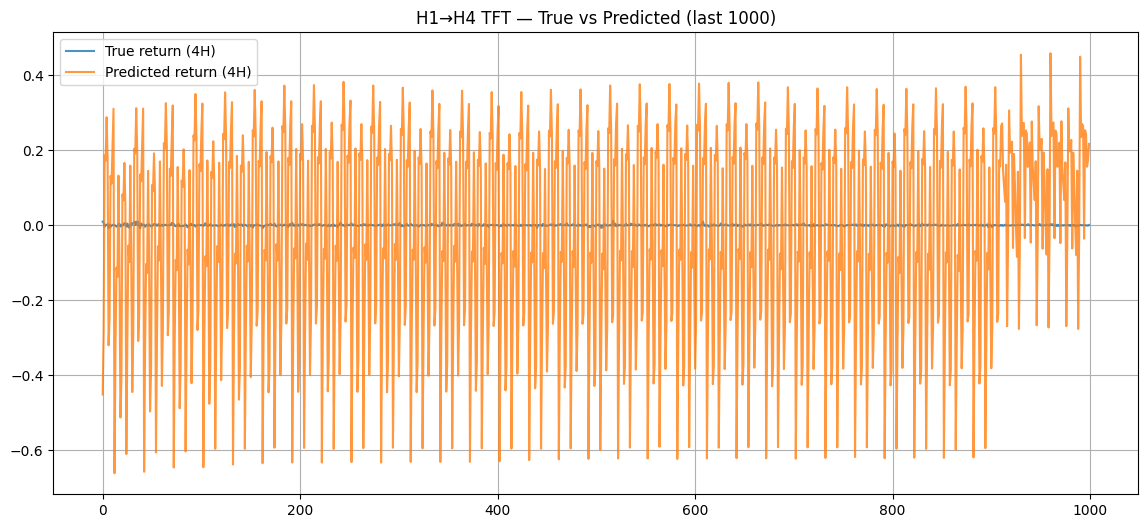

Total pips: 944.03143
Sharpe-like (mean/std): 0.016884545


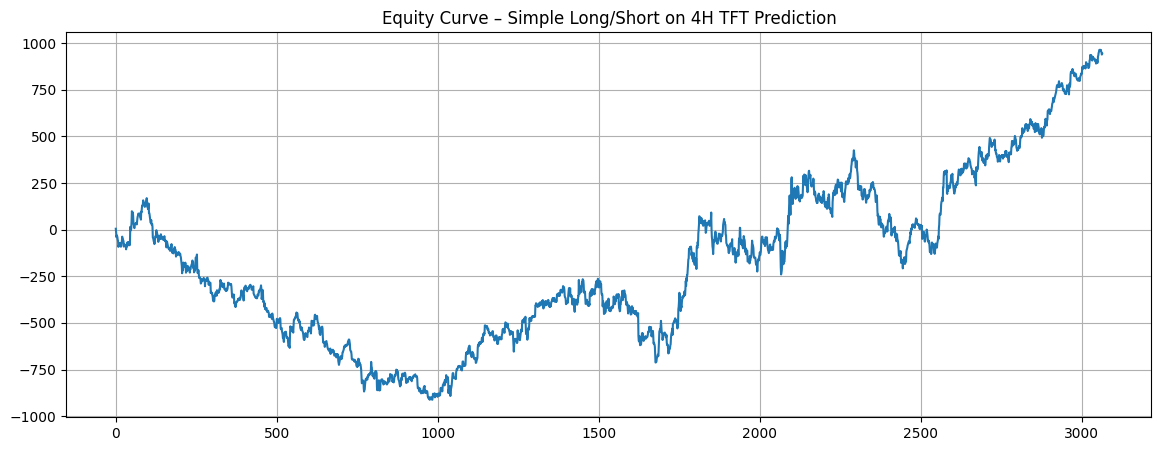

In [14]:
# ============================================
#   FINAL EVAL: METRICS + PLOTS + BASELINE PIPS
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# Extract results from val_results dataframe
true = val_results["true_return"].values
pred = val_results["pred_return"].values

# ---- Metrics ----
mse = np.mean((true - pred) ** 2)
mae = np.mean(np.abs(true - pred))

# direction accuracy (ignore very small returns)
mask = np.abs(true) > 1e-6
dir_acc = np.mean(np.sign(pred[mask]) == np.sign(true[mask]))

# convert to pips
mae_pips = mae * 10000

print("=== H1→H4 Multi-Timeframe TFT — Metrics ===")
print(f"MSE: {mse:.8f}")
print(f"MAE: {mae:.8f}")
print(f"Direction accuracy: {dir_acc*100:.2f}%")
print(f"Approx MAE in pips (4H): {mae_pips:.2f} pips")


# ============================================================
# Plot: True vs Predicted (last 1000 points for readability)
# ============================================================
plt.figure(figsize=(14, 6))
plt.plot(true[-1000:], label="True return (4H)", alpha=0.8)
plt.plot(pred[-1000:], label="Predicted return (4H)", alpha=0.8)
plt.title("H1→H4 TFT — True vs Predicted (last 1000)")
plt.legend()
plt.grid()
plt.show()


# ============================================================
# Baseline simple pips strategy:
#   Long if prediction > 0, Short if prediction < 0
#   Profit = sign(pred) * true_return
# ============================================================

signals = np.sign(pred)
pnl_pips = signals * true * 10000  # each trade pips outcome
equity_curve = np.cumsum(pnl_pips)

print("Total pips:", equity_curve[-1])
print("Sharpe-like (mean/std):", np.mean(pnl_pips) / np.std(pnl_pips+1e-6))

plt.figure(figsize=(14, 5))
plt.plot(equity_curve)
plt.title("Equity Curve – Simple Long/Short on 4H TFT Prediction")
plt.grid()
plt.show()


In [2]:
import os

[x for x in os.listdir() if "eurusd_mt_h1_to_h4" in x]


[]

In [16]:
from pytorch_forecasting.models import TemporalFusionTransformer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = r"C:\Users\admin\Desktop\Forex_algo\code\lightning_logs\version_73\checkpoints\eurusd_mt_h1_to_h4-epoch=28-val_loss=0.001256.ckpt"

# 1) Load ONLY the model checkpoint
tft_mt = TemporalFusionTransformer.load_from_checkpoint(
    ckpt_path,
    map_location=device
)

# 2) Recover the training dataset directly from checkpoint
training = tft_mt.dataset

# 3) Build validation dataset automatically
validation = training.get_validation_set()

# 4) Dataloaders
from torch.utils.data import DataLoader
train_dataloader = DataLoader(training, batch_size=64, shuffle=False, num_workers=0)
val_dataloader = DataLoader(validation, batch_size=64, shuffle=False, num_workers=0)

tft_mt.to(device)
tft_mt.eval()

print("Loaded model + dataset ✔️")
print("Training samples:", len(training))
print("Validation samples:", len(validation))


AttributeError: 'TemporalFusionTransformer' object has no attribute 'dataset'